In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
test = pd.read_csv("../data/processed/failure_test.csv")

print("Test shape:", test.shape)

test.head()

Test shape: (7000, 14)


,asset_id,section_id,department,asset_type,snapshot_date,asset_age_years,condition_score,criticality,usage_factor,weather_stress,historical_failure_count,historical_downtime_hours,days_since_last_failure,failure_within_30_days
0,ASSET00001,RTM-VAD-01,TRACTION,OHE,2026-01-01,15,89.209179,6,0.565548,0.753081,0,0.0,NaN,0
1,ASSET00001,RTM-VAD-01,TRACTION,OHE,2026-02-01,15,89.577927,6,0.565548,0.955104,0,0.0,NaN,0
2,ASSET00001,RTM-VAD-01,TRACTION,OHE,2026-03-01,15,80.757906,6,0.565548,0.629812,0,0.0,NaN,0
3,ASSET00001,RTM-VAD-01,TRACTION,OHE,2026-04-01,15,93.547746,6,0.565548,0.486593,0,0.0,NaN,0
4,ASSET00001,RTM-VAD-01,TRACTION,OHE,2026-05-01,15,90.411221,6,0.565548,0.638689,0,0.0,NaN,0


In [3]:
print(test["failure_within_30_days"].value_counts())

print("\nPercentages:")
print(
    test["failure_within_30_days"]
    .value_counts(normalize=True)
    .mul(100)
)

failure_within_30_days
0    6948
1      52
Name: count, dtype: int64

Percentages:
failure_within_30_days
0    99.257143
1     0.742857
Name: proportion, dtype: float64


In [4]:
logistic = pd.read_csv(
    "../data/predictions/logistic_failure_predictions.csv"
)

decision_tree = pd.read_csv(
    "../data/predictions/decision_tree_failure_predictions.csv"
)

random_forest = pd.read_csv(
    "../data/predictions/random_forest_failure_predictions.csv"
)

xgboost = pd.read_csv(
    "../data/predictions/xgboost_failure_predictions.csv"
)

In [5]:
print("Logistic Regression:", logistic.shape)
print("Decision Tree:", decision_tree.shape)
print("Random Forest:", random_forest.shape)
print("XGBoost:", xgboost.shape)

Logistic Regression: (7000, 11)
Decision Tree: (7000, 11)
Random Forest: (7000, 11)
XGBoost: (7000, 10)


In [6]:
print("Actual test rows:", len(test))

print("Logistic rows:", len(logistic))
print("Decision Tree rows:", len(decision_tree))
print("Random Forest rows:", len(random_forest))
print("XGBoost rows:", len(xgboost))

Actual test rows: 7000
Logistic rows: 7000
Decision Tree rows: 7000
Random Forest rows: 7000
XGBoost rows: 7000


In [7]:
print("\nTest date range:")
print(test["snapshot_date"].min(), "to", test["snapshot_date"].max())

print("\nXGBoost date range:")
print(xgboost["snapshot_date"].min(), "to", xgboost["snapshot_date"].max())


Test date range:
2026-01-01 to 2026-07-01

XGBoost date range:
2026-01-01 to 2026-07-01


In [8]:
def evaluate_predictions(data):
    
    y_true = data["failure_within_30_days"]
    y_pred = data["predicted_failure"]
    y_probability = data["failure_probability"]
    
    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability
        ),
        "PR_AUC": average_precision_score(
            y_true,
            y_probability
        )
    }
    
    return results

In [9]:
logistic_results = evaluate_predictions(logistic)

tree_results = evaluate_predictions(decision_tree)

rf_results = evaluate_predictions(random_forest)

xgb_results = evaluate_predictions(xgboost)

In [10]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_results
    },
    {
        "Model": "Decision Tree",
        **tree_results
    },
    {
        "Model": "Random Forest",
        **rf_results
    },
    {
        "Model": "XGBoost",
        **xgb_results
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.452143,0.010861,0.807692,0.021434,0.685438,0.031309
1,Decision Tree,0.438143,0.008112,0.615385,0.016012,0.569018,0.013108
2,Random Forest,0.883429,0.005181,0.076923,0.009709,0.532162,0.008935
3,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868,0.008403


In [11]:
print("Ranking by F1:")
display(
    comparison.sort_values(
        "F1",
        ascending=False
    )
)

Ranking by F1:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.452143,0.010861,0.807692,0.021434,0.685438,0.031309
3,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868,0.008403
1,Decision Tree,0.438143,0.008112,0.615385,0.016012,0.569018,0.013108
2,Random Forest,0.883429,0.005181,0.076923,0.009709,0.532162,0.008935


In [12]:
print("Ranking by PR-AUC:")
display(
    comparison.sort_values(
        "PR_AUC",
        ascending=False
    )
)

Ranking by PR-AUC:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.452143,0.010861,0.807692,0.021434,0.685438,0.031309
1,Decision Tree,0.438143,0.008112,0.615385,0.016012,0.569018,0.013108
2,Random Forest,0.883429,0.005181,0.076923,0.009709,0.532162,0.008935
3,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868,0.008403


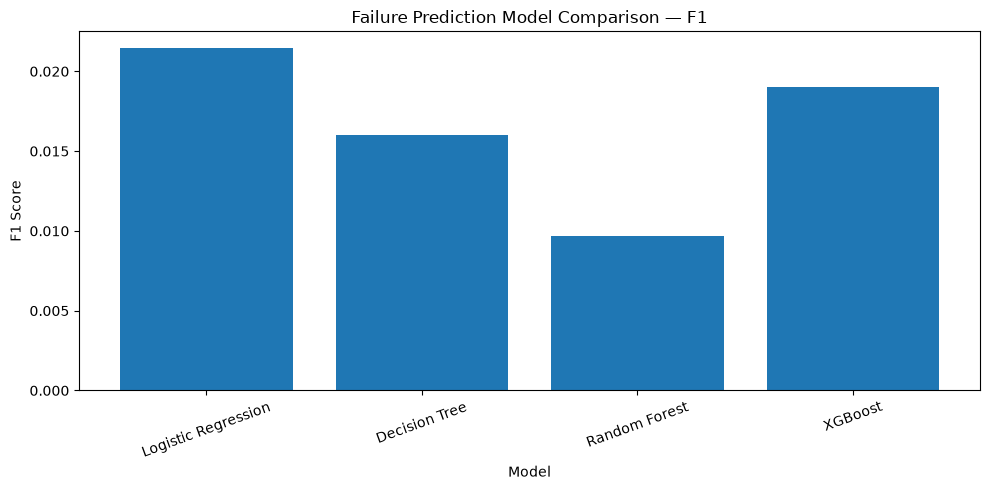

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["F1"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Failure Prediction Model Comparison — F1")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

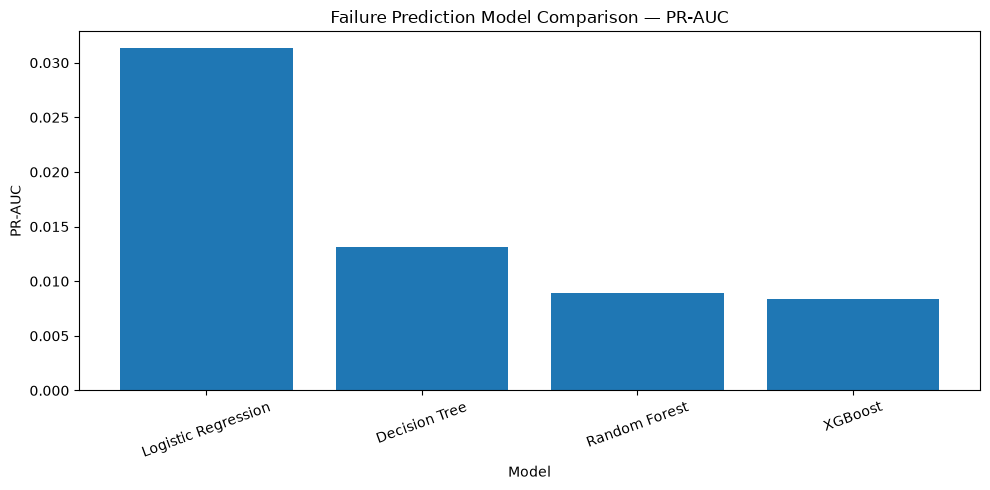

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["PR_AUC"]
)

plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.title("Failure Prediction Model Comparison — PR-AUC")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [15]:
models = {
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgboost
}

In [16]:
for name, data in models.items():
    
    cm = confusion_matrix(
        data["failure_within_30_days"],
        data["predicted_failure"]
    )
    
    print("\n" + name)
    print(cm)


Logistic Regression
[[3123 3825]
 [  10   42]]

Decision Tree
[[3035 3913]
 [  20   32]]

Random Forest
[[6180  768]
 [  48    4]]

XGBoost
[[6375  573]
 [  46    6]]


In [17]:
def threshold_analysis(data):
    
    y_true = data["failure_within_30_days"]
    probabilities = data["failure_probability"]
    
    thresholds = np.arange(0.05, 0.96, 0.05)
    
    results = []
    
    for threshold in thresholds:
        
        y_pred = (
            probabilities >= threshold
        ).astype(int)
        
        results.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        })
    
    return pd.DataFrame(results)

In [18]:
logistic_thresholds = threshold_analysis(logistic)

logistic_thresholds

,Threshold,Precision,Recall,F1
0,0.05,0.007429,1.000000,0.014748
1,0.10,0.007429,1.000000,0.014748
2,0.15,0.007433,1.000000,0.014756
3,0.20,0.007377,0.980769,0.014645
4,0.25,0.007435,0.961538,0.014756
5,0.30,0.007867,0.961538,0.015605
6,0.35,0.008301,0.942308,0.016457
7,0.40,0.009098,0.923077,0.018018
8,0.45,0.009894,0.865385,0.019565
9,0.50,0.010861,0.807692,0.021434


In [19]:
best_logistic_threshold = logistic_thresholds.loc[
    logistic_thresholds["F1"].idxmax()
]

best_logistic_threshold

Threshold    0.900000
Precision    0.115385
Recall       0.057692
F1           0.076923
Name: 17, dtype: float64

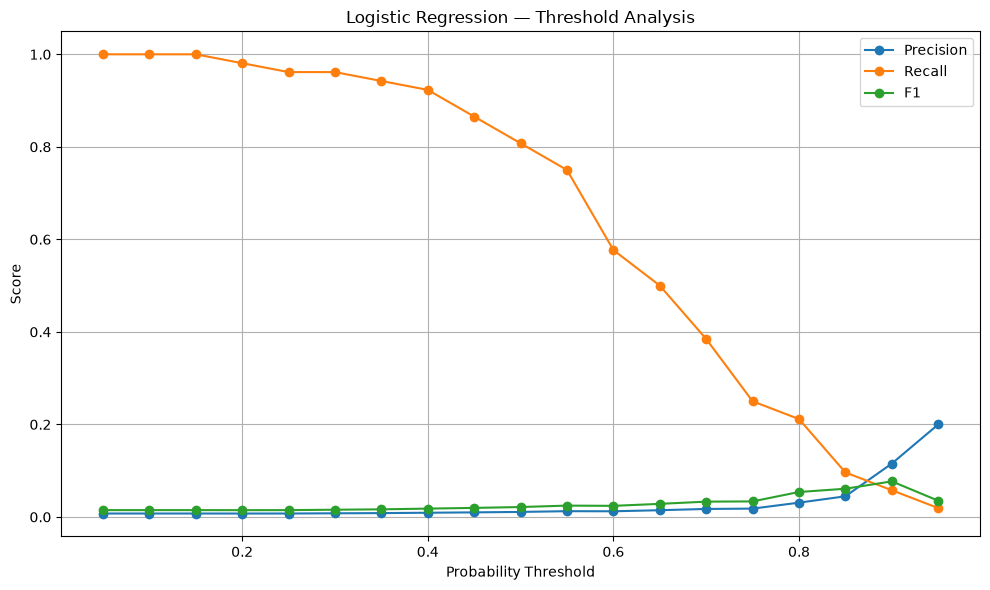

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    logistic_thresholds["Threshold"],
    logistic_thresholds["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    logistic_thresholds["Threshold"],
    logistic_thresholds["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    logistic_thresholds["Threshold"],
    logistic_thresholds["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression — Threshold Analysis")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
threshold_results = {}

for name, data in models.items():
    
    threshold_results[name] = threshold_analysis(data)

In [22]:
best_thresholds = []

for name, results in threshold_results.items():
    
    best_row = results.loc[
        results["F1"].idxmax()
    ]
    
    best_thresholds.append({
        "Model": name,
        "Best Threshold": best_row["Threshold"],
        "Precision": best_row["Precision"],
        "Recall": best_row["Recall"],
        "F1": best_row["F1"]
    })

best_thresholds = pd.DataFrame(best_thresholds)

best_thresholds.sort_values(
    "F1",
    ascending=False
)

,Model,Best Threshold,Precision,Recall,F1
0,Logistic Regression,0.90,0.115385,0.057692,0.076923
1,Decision Tree,0.75,0.017544,0.211538,0.032401
3,XGBoost,0.55,0.013624,0.096154,0.023866
2,Random Forest,0.60,0.013158,0.038462,0.019608


In [23]:
best_thresholds.sort_values(
    "F1",
    ascending=False
)

,Model,Best Threshold,Precision,Recall,F1
0,Logistic Regression,0.90,0.115385,0.057692,0.076923
1,Decision Tree,0.75,0.017544,0.211538,0.032401
3,XGBoost,0.55,0.013624,0.096154,0.023866
2,Random Forest,0.60,0.013158,0.038462,0.019608


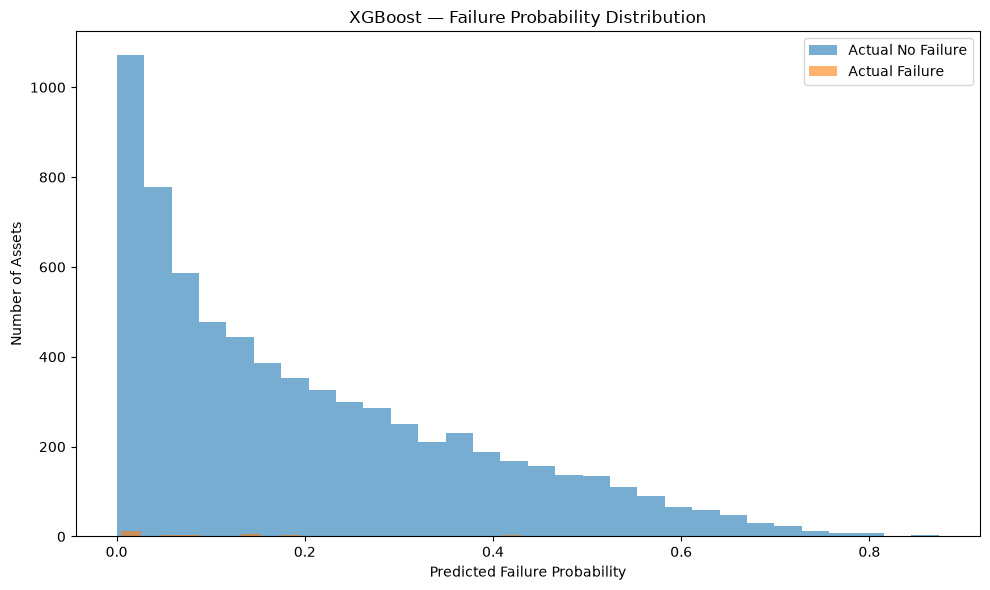

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(
    xgboost.loc[
        xgboost["failure_within_30_days"] == 0,
        "failure_probability"
    ],
    bins=30,
    alpha=0.6,
    label="Actual No Failure"
)

plt.hist(
    xgboost.loc[
        xgboost["failure_within_30_days"] == 1,
        "failure_probability"
    ],
    bins=30,
    alpha=0.6,
    label="Actual Failure"
)

plt.xlabel("Predicted Failure Probability")
plt.ylabel("Number of Assets")
plt.title("XGBoost — Failure Probability Distribution")
plt.legend()

plt.tight_layout()
plt.show()

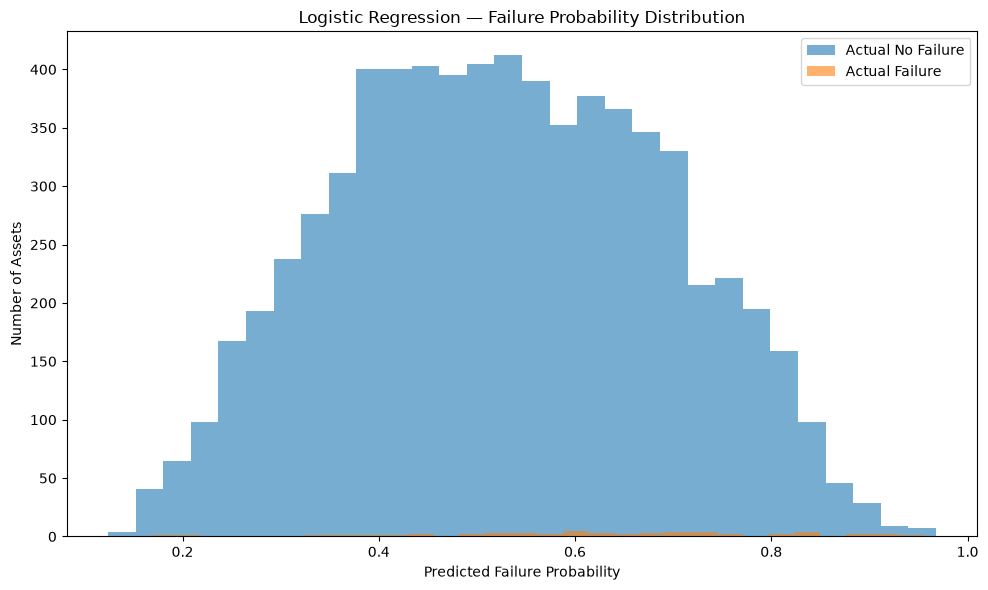

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    logistic.loc[
        logistic["failure_within_30_days"] == 0,
        "failure_probability"
    ],
    bins=30,
    alpha=0.6,
    label="Actual No Failure"
)

plt.hist(
    logistic.loc[
        logistic["failure_within_30_days"] == 1,
        "failure_probability"
    ],
    bins=30,
    alpha=0.6,
    label="Actual Failure"
)

plt.xlabel("Predicted Failure Probability")
plt.ylabel("Number of Assets")
plt.title("Logistic Regression — Failure Probability Distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
probability_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Mean Probability - No Failure": [
        logistic.loc[
            logistic["failure_within_30_days"] == 0,
            "failure_probability"
        ].mean(),

        decision_tree.loc[
            decision_tree["failure_within_30_days"] == 0,
            "failure_probability"
        ].mean(),

        random_forest.loc[
            random_forest["failure_within_30_days"] == 0,
            "failure_probability"
        ].mean(),

        xgboost.loc[
            xgboost["failure_within_30_days"] == 0,
            "failure_probability"
        ].mean()
    ],
    "Mean Probability - Failure": [
        logistic.loc[
            logistic["failure_within_30_days"] == 1,
            "failure_probability"
        ].mean(),

        decision_tree.loc[
            decision_tree["failure_within_30_days"] == 1,
            "failure_probability"
        ].mean(),

        random_forest.loc[
            random_forest["failure_within_30_days"] == 1,
            "failure_probability"
        ].mean(),

        xgboost.loc[
            xgboost["failure_within_30_days"] == 1,
            "failure_probability"
        ].mean()
    ]
})

probability_summary

,Model,Mean Probability - No Failure,Mean Probability - Failure
0,Logistic Regression,0.526571,0.638768
1,Decision Tree,0.429313,0.475963
2,Random Forest,0.300519,0.315862
3,XGBoost,0.203750,0.211136


In [27]:
test_baseline = test.copy()

condition_risk = (
    (100 - test_baseline["condition_score"]) / 100
)

age_risk = (
    test_baseline["asset_age_years"] / 30
).clip(0, 1)

failure_history_risk = (
    test_baseline["historical_failure_count"] / 5
).clip(0, 1)

criticality_risk = (
    (test_baseline["criticality"] - 5) / 5
).clip(0, 1)

usage_risk = (
    test_baseline["usage_factor"] / 1.5
).clip(0, 1)

weather_risk = test_baseline["weather_stress"].clip(0, 1)

test_baseline["risk_score"] = (
    0.30 * condition_risk +
    0.15 * age_risk +
    0.20 * failure_history_risk +
    0.20 * criticality_risk +
    0.10 * usage_risk +
    0.05 * weather_risk
)

test_baseline["predicted_failure"] = (
    test_baseline["risk_score"] >= 0.50
).astype(int)

test_baseline[
    [
        "asset_id",
        "snapshot_date",
        "failure_within_30_days",
        "risk_score",
        "predicted_failure"
    ]
].head()

,asset_id,snapshot_date,failure_within_30_days,risk_score,predicted_failure
0,ASSET00001,2026-01-01,0,0.222730,0
1,ASSET00001,2026-02-01,0,0.231725,0
2,ASSET00001,2026-03-01,0,0.241920,0
3,ASSET00001,2026-04-01,0,0.196390,0
4,ASSET00001,2026-05-01,0,0.213404,0


In [28]:
baseline_results = {
    "Accuracy": accuracy_score(
        test_baseline["failure_within_30_days"],
        test_baseline["predicted_failure"]
    ),
    
    "Precision": precision_score(
        test_baseline["failure_within_30_days"],
        test_baseline["predicted_failure"],
        zero_division=0
    ),
    
    "Recall": recall_score(
        test_baseline["failure_within_30_days"],
        test_baseline["predicted_failure"],
        zero_division=0
    ),
    
    "F1": f1_score(
        test_baseline["failure_within_30_days"],
        test_baseline["predicted_failure"],
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        test_baseline["failure_within_30_days"],
        test_baseline["risk_score"]
    ),
    
    "PR_AUC": average_precision_score(
        test_baseline["failure_within_30_days"],
        test_baseline["risk_score"]
    )
}

baseline_results

{'Accuracy': 0.8992857142857142,
 'Precision': 0.021961932650073207,
 'Recall': 0.28846153846153844,
 'F1': 0.04081632653061224,
 'ROC_AUC': 0.6271256808821576,
 'PR_AUC': 0.017666023078523243}

In [29]:
comparison_with_baseline = pd.DataFrame([
    {
        "Model": "Rule-Based Baseline",
        **baseline_results
    },
    {
        "Model": "Logistic Regression",
        **logistic_results
    },
    {
        "Model": "Decision Tree",
        **tree_results
    },
    {
        "Model": "Random Forest",
        **rf_results
    },
    {
        "Model": "XGBoost",
        **xgb_results
    }
])

comparison_with_baseline

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Rule-Based Baseline,0.899286,0.021962,0.288462,0.040816,0.627126,0.017666
1,Logistic Regression,0.452143,0.010861,0.807692,0.021434,0.685438,0.031309
2,Decision Tree,0.438143,0.008112,0.615385,0.016012,0.569018,0.013108
3,Random Forest,0.883429,0.005181,0.076923,0.009709,0.532162,0.008935
4,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868,0.008403


In [30]:
all_models = {
    "Rule-Based Baseline": test_baseline,
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgboost
}

In [31]:
for name, data in all_models.items():
    
    cm = confusion_matrix(
        data["failure_within_30_days"],
        data["predicted_failure"]
    )
    
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print(cm)


Rule-Based Baseline
[[6280  668]
 [  37   15]]

Logistic Regression
[[3123 3825]
 [  10   42]]

Decision Tree
[[3035 3913]
 [  20   32]]

Random Forest
[[6180  768]
 [  48    4]]

XGBoost
[[6375  573]
 [  46    6]]


In [32]:
error_analysis = []

for name, data in all_models.items():
    
    y_true = data["failure_within_30_days"]
    y_pred = data["predicted_failure"]
    
    cm = confusion_matrix(y_true, y_pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    error_analysis.append({
        "Model": name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

error_analysis = pd.DataFrame(error_analysis)

error_analysis

,Model,True Negatives,False Positives,False Negatives,True Positives
0,Rule-Based Baseline,6280,668,37,15
1,Logistic Regression,3123,3825,10,42
2,Decision Tree,3035,3913,20,32
3,Random Forest,6180,768,48,4
4,XGBoost,6375,573,46,6
